In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual style
sns.set(style="whitegrid")

# Download 1 year of AAPL stock data
aapl = yf.Ticker("AAPL")
data = aapl.history(period="1y")

# Basic information
print("Summary Info:")
print(data.describe())

# Moving Averages
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

# Daily Returns
data['Daily Return'] = data['Close'].pct_change()

# Cumulative Returns
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()
aapl = yf.Ticker("AAPL")
df = aapl.history(period="1y")
df['Daily_Return'] = df['Close'].pct_change()

# Drop NaN
returns = df['Daily_Return'].dropna()

# === Numerical Statistics ===
stats_summary = {
    "Mean Daily Return": returns.mean(),
    "Median Daily Return": returns.median(),
    "Standard Deviation (Volatility)": returns.std(),
    "Variance": returns.var(),
    "Skewness": returns.skew(),
    "Kurtosis": returns.kurtosis(),
    "Min Return": returns.min(),
    "Max Return": returns.max(),
    "25th Percentile": returns.quantile(0.25),
    "75th Percentile": returns.quantile(0.75),
    "Value at Risk (95%)": np.percentile(returns, 5),
    "Sharpe Ratio (Annualized)": (returns.mean() / returns.std()) * np.sqrt(252)
}

# Max drawdown calculation
df['Cumulative'] = (1 + returns).cumprod()
df['Rolling_Max'] = df['Cumulative'].cummax()
df['Drawdown'] = df['Cumulative'] / df['Rolling_Max'] - 1
max_drawdown = df['Drawdown'].min()
stats_summary["Max Drawdown"] = max_drawdown

# Convert to DataFrame and print
summary_df = pd.DataFrame(stats_summary, index=["AAPL"]).T
print(summary_df)



Summary Info:
             Open        High         Low       Close        Volume  \
count  250.000000  250.000000  250.000000  250.000000  2.500000e+02   
mean   222.007443  224.579265  219.663116  222.297051  5.348207e+07   
std     15.831769   15.252874   16.087888   15.719331  2.745644e+07   
min    171.724805  190.090729  168.988411  172.194199  2.323470e+07   
25%    210.619995  213.227252  208.222788  211.307495  3.951048e+07   
50%    223.828230  225.813947  222.015620  223.690399  4.667505e+07   
75%    232.447929  234.263573  229.182156  232.515671  5.721778e+07   
max    257.568678  259.474086  257.010028  258.396667  3.186799e+08   

        Dividends  Stock Splits  
count  250.000000         250.0  
mean     0.004040           0.0  
std      0.031751           0.0  
min      0.000000           0.0  
25%      0.000000           0.0  
50%      0.000000           0.0  
75%      0.000000           0.0  
max      0.260000           0.0  
                                      AA

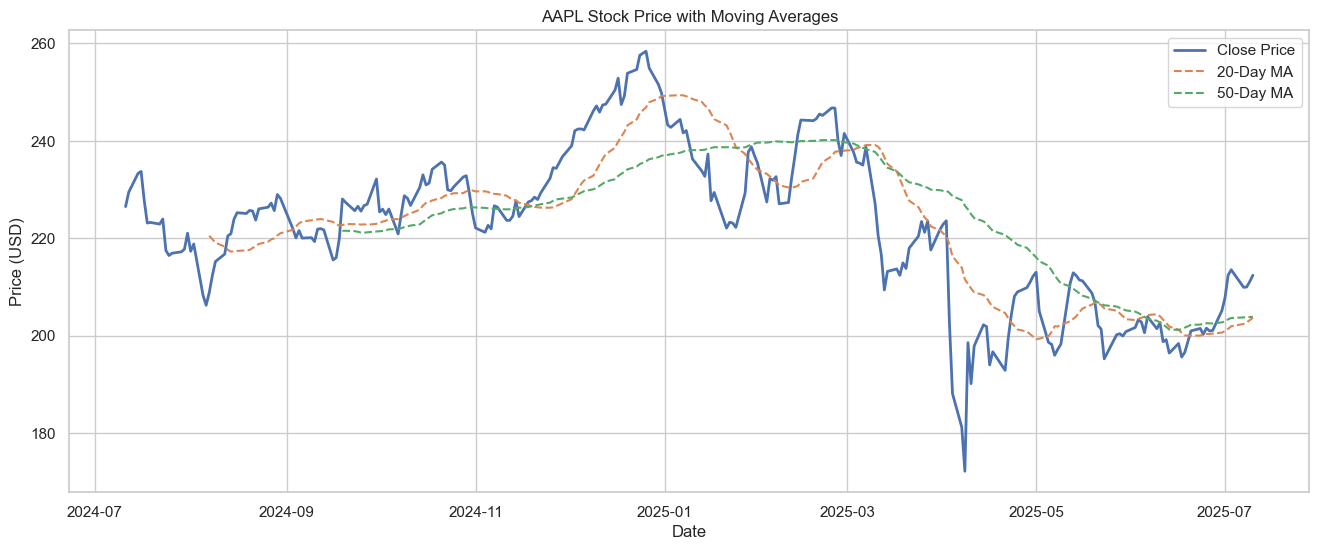

In [4]:
# Visualization

plt.figure(figsize=(16, 6))
plt.plot(data['Close'], label='Close Price', linewidth=2)
plt.plot(data['MA20'], label='20-Day MA', linestyle='--')
plt.plot(data['MA50'], label='50-Day MA', linestyle='--')
plt.title("AAPL Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


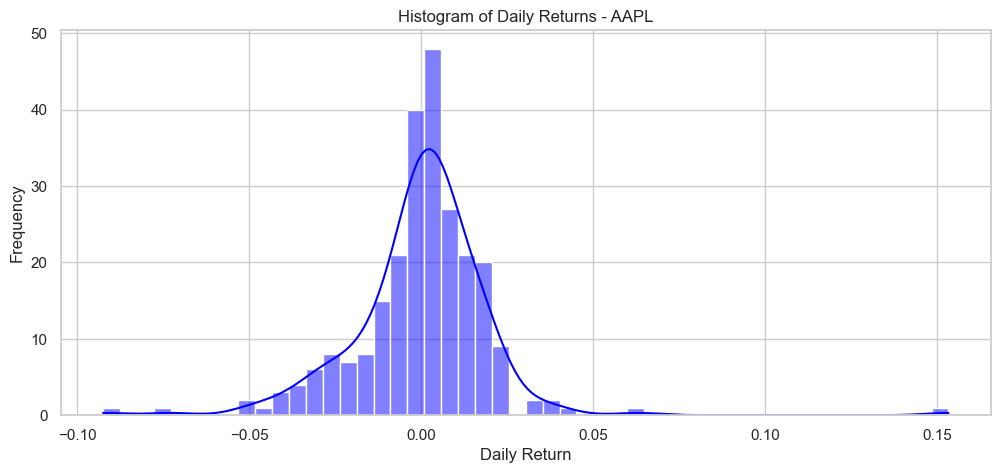

In [5]:
# Daily Return Histogram
plt.figure(figsize=(12, 5))
sns.histplot(data['Daily Return'].dropna(), bins=50, kde=True, color='blue')
plt.title("Histogram of Daily Returns - AAPL")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


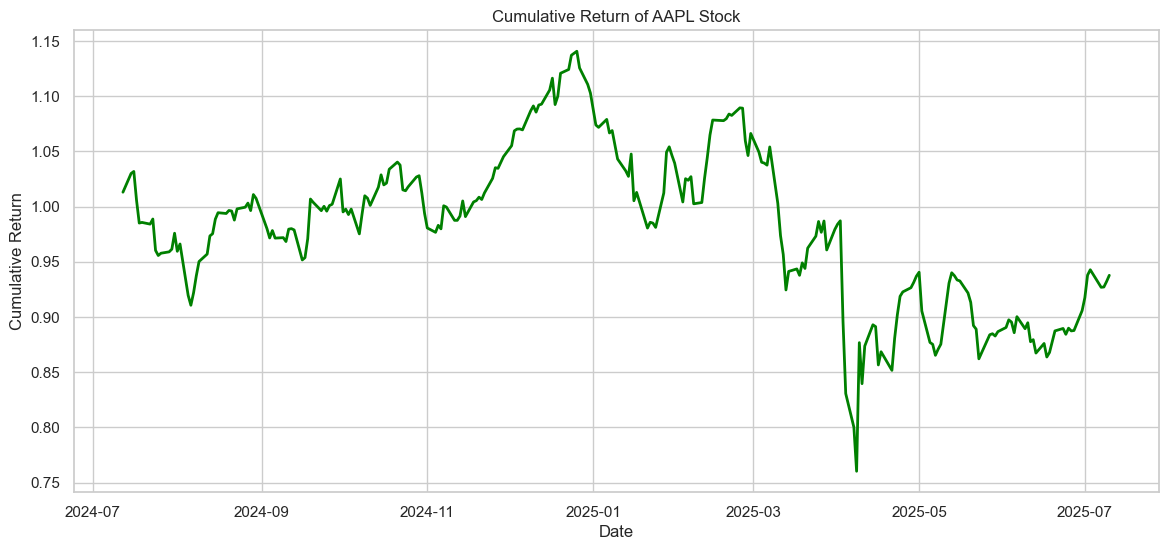

In [6]:
# Cumulative Returns Plot
plt.figure(figsize=(14, 6))
plt.plot(data['Cumulative Return'], color='green', linewidth=2)
plt.title("Cumulative Return of AAPL Stock")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

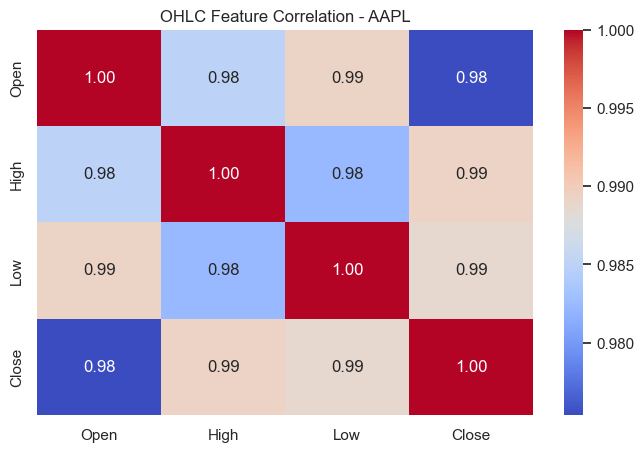

In [7]:
# Correlation Heatmap of OHLC
plt.figure(figsize=(8, 5))
sns.heatmap(data[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("OHLC Feature Correlation - AAPL")
plt.show()

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid')

# Load AAPL data for the past 1 year
aapl = yf.Ticker("AAPL")
df = aapl.history(period="1y")

# Add 20-day rolling mean and standard deviation (for Bollinger Bands)
df['MA20'] = df['Close'].rolling(window=20).mean()
df['STD20'] = df['Close'].rolling(window=20).std()
df['Upper_Band'] = df['MA20'] + (df['STD20'] * 2)
df['Lower_Band'] = df['MA20'] - (df['STD20'] * 2)

# Calculate RSI
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# Calculate MACD
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Daily return and Sharpe Ratio
df['Daily_Return'] = df['Close'].pct_change()
mean_return = df['Daily_Return'].mean()
volatility = df['Daily_Return'].std()
sharpe_ratio = (mean_return / volatility) * np.sqrt(252)  # Annualized

# Display Sharpe Ratio
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")



Annualized Sharpe Ratio: -0.05


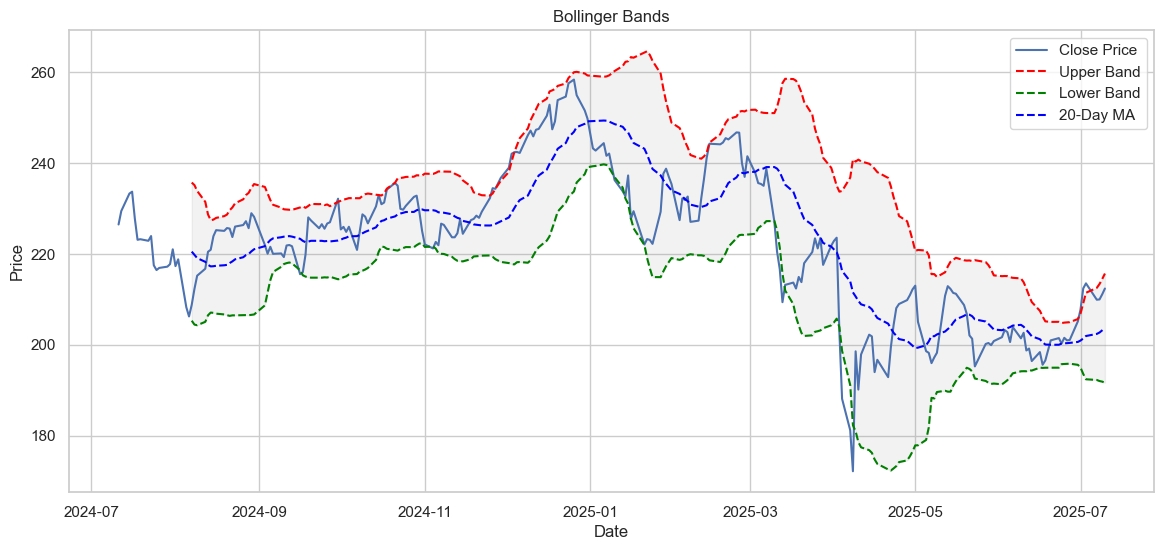

In [9]:
# === Visualizations ===

# Bollinger Bands
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', linewidth=1.5)
plt.plot(df['Upper_Band'], label='Upper Band', linestyle='--', color='red')
plt.plot(df['Lower_Band'], label='Lower Band', linestyle='--', color='green')
plt.plot(df['MA20'], label='20-Day MA', linestyle='--', color='blue')
plt.fill_between(df.index, df['Lower_Band'], df['Upper_Band'], color='grey', alpha=0.1)
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

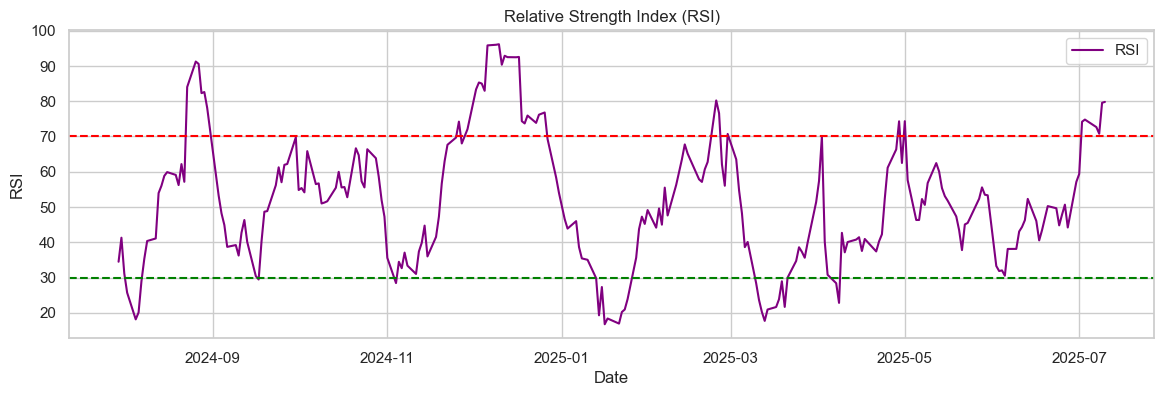

In [10]:
# RSI Plot
plt.figure(figsize=(14, 4))
plt.plot(df['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()

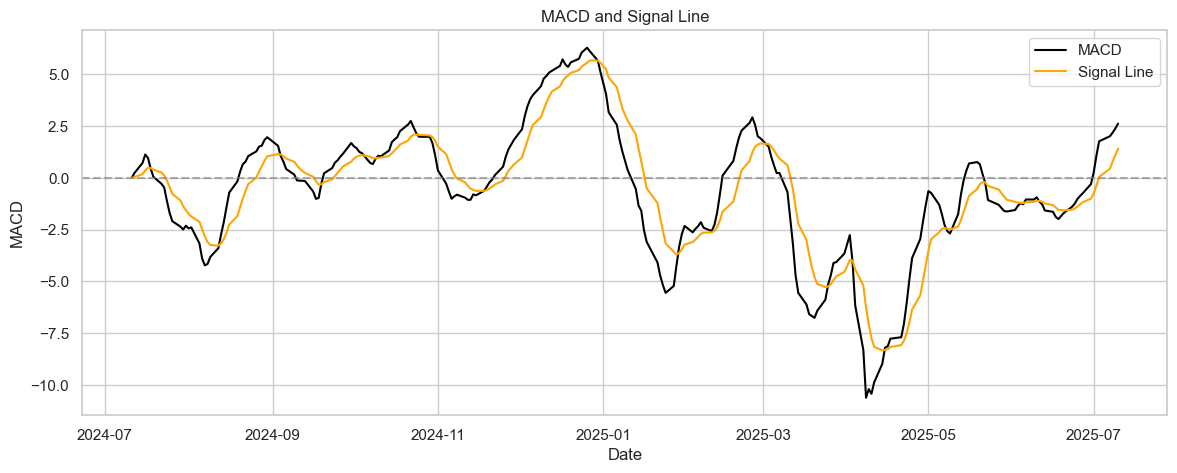

In [11]:
# MACD Plot
plt.figure(figsize=(14, 5))
plt.plot(df['MACD'], label='MACD', color='black')
plt.plot(df['Signal_Line'], label='Signal Line', color='orange')
plt.axhline(0, linestyle='--', alpha=0.6, color='grey')
plt.title('MACD and Signal Line')
plt.xlabel('Date')
plt.ylabel('MACD')
plt.legend()
plt.grid(True)
plt.show()
